<a href="https://colab.research.google.com/github/AkshitaNipane/Machine-Learning-TAE/blob/main/model_2_ml_(Random_Forest_).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/ML_DATASET/customer_feedback_satisfaction.csv')

print("Dataset Preview:")
print(df.head())

Dataset Preview:
   CustomerID  Age  Gender Country  Income  ProductQuality  ServiceQuality  \
0           1   56    Male      UK   83094               5               8   
1           2   69    Male      UK   86860              10               2   
2           3   46  Female     USA   60173               8              10   
3           4   32  Female      UK   73884               7              10   
4           5   60    Male      UK   97546               6               4   

   PurchaseFrequency FeedbackScore LoyaltyLevel  SatisfactionScore  
0                  5           Low       Bronze              100.0  
1                  8        Medium         Gold              100.0  
2                 18        Medium       Silver              100.0  
3                 16           Low         Gold              100.0  
4                 13           Low       Bronze               82.0  


In [ ]:
df.shape

(38444, 11)

In [ ]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Country', 'Income', 'ProductQuality',
       'ServiceQuality', 'PurchaseFrequency', 'FeedbackScore', 'LoyaltyLevel',
       'SatisfactionScore'],
      dtype='object')

In [ ]:
df.describe()

,CustomerID,Age,Income,ProductQuality,ServiceQuality,PurchaseFrequency,SatisfactionScore
count,38444.000000,38444.000000,38444.000000,38444.000000,38444.000000,38444.000000,38444.000000
mean,19222.500000,43.496853,75076.619238,5.494746,5.492769,10.453881,85.276409
std,11097.971211,14.972748,25975.752966,2.873192,2.875812,5.765621,16.898577
min,1.000000,18.000000,30001.000000,1.000000,1.000000,1.000000,4.280000
25%,9611.750000,31.000000,52624.500000,3.000000,3.000000,5.000000,74.470000
50%,19222.500000,43.000000,75236.000000,5.000000,5.000000,10.000000,91.270000
75%,28833.250000,56.000000,97606.750000,8.000000,8.000000,15.000000,100.000000
max,38444.000000,69.000000,119999.000000,10.000000,10.000000,20.000000,100.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38444 entries, 0 to 38443
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         38444 non-null  int64  
 1   Age                38444 non-null  int64  
 2   Gender             38444 non-null  object 
 3   Country            38444 non-null  object 
 4   Income             38444 non-null  int64  
 5   ProductQuality     38444 non-null  int64  
 6   ServiceQuality     38444 non-null  int64  
 7   PurchaseFrequency  38444 non-null  int64  
 8   FeedbackScore      38444 non-null  object 
 9   LoyaltyLevel       38444 non-null  object 
 10  SatisfactionScore  38444 non-null  float64
dtypes: float64(1), int64(6), object(4)
memory usage: 3.2+ MB


In [ ]:
import pandas as pd

rf_summary = pd.DataFrame({
    'Split': ['80:20', '70:30'],
    'Accuracy': [rf_acc_80, rf_acc_70]
})

print("\nFinal Accuracy Table:")
print(rf_summary)


Final Accuracy Table:
   Split  Accuracy
0  80:20       0.0
1  70:30       0.0


In [ ]:
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# Convert 'SatisfactionScore' to a categorical variable for classification
# Binning the continuous 'SatisfactionScore' into categories
df['SatisfactionCategory'] = pd.cut(df['SatisfactionScore'],
                                    bins=[0, 60, 80, 100],
                                    labels=['Low', 'Medium', 'High'],
                                    include_lowest=True)

X = df.drop(['SatisfactionScore', 'SatisfactionCategory'], axis=1)
y = df['SatisfactionCategory']

# Scaling (optional but kept for similarity)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
def rf_model(split_ratio):
    print(f"\n===== RANDOM FOREST ({int(split_ratio*100)}:{int((1-split_ratio)*100)}) =====")

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=(1-split_ratio), random_state=42
    )

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    result_table = pd.DataFrame({
        'Actual': y_test.values,
        'Predicted': y_pred
    })
    print("\nAccuracy:", acc)
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    print("\nOutput Table:")
    print(result_table.head(10))

    return acc, result_table

In [ ]:
acc, result_table = rf_model(0.7)


===== RANDOM FOREST (70:30) =====

Accuracy: 0.8085659788451535

Confusion Matrix:
 [[7210   15  518]
 [  32  698  442]
 [ 942  259 1418]]

Classification Report:
               precision    recall  f1-score   support

        High       0.88      0.93      0.91      7743
         Low       0.72      0.60      0.65      1172
      Medium       0.60      0.54      0.57      2619

    accuracy                           0.81     11534
   macro avg       0.73      0.69      0.71     11534
weighted avg       0.80      0.81      0.80     11534


Output Table:
   Actual Predicted
0    High    Medium
1    High      High
2    High      High
3    High    Medium
4    High      High
5  Medium    Medium
6    High      High
7    High      High
8  Medium    Medium
9    High      High


In [ ]:
rf_acc_70, rf_table_70 = rf_model(0.7)


===== RANDOM FOREST (70:30) =====

Accuracy: 0.8085659788451535

Confusion Matrix:
 [[7210   15  518]
 [  32  698  442]
 [ 942  259 1418]]

Classification Report:
               precision    recall  f1-score   support

        High       0.88      0.93      0.91      7743
         Low       0.72      0.60      0.65      1172
      Medium       0.60      0.54      0.57      2619

    accuracy                           0.81     11534
   macro avg       0.73      0.69      0.71     11534
weighted avg       0.80      0.81      0.80     11534


Output Table:
   Actual Predicted
0    High    Medium
1    High      High
2    High      High
3    High    Medium
4    High      High
5  Medium    Medium
6    High      High
7    High      High
8  Medium    Medium
9    High      High



===== RANDOM FOREST (80:19) =====

Accuracy: 0.8114189101313565

Confusion Matrix:
 [[4840    8  319]
 [  19  457  278]
 [ 641  185  942]]

Classification Report:
               precision    recall  f1-score   support

        High       0.88      0.94      0.91      5167
         Low       0.70      0.61      0.65       754
      Medium       0.61      0.53      0.57      1768

    accuracy                           0.81      7689
   macro avg       0.73      0.69      0.71      7689
weighted avg       0.80      0.81      0.80      7689


Output Table:
   Actual Predicted
0    High    Medium
1    High      High
2    High      High
3    High    Medium
4    High      High
5  Medium    Medium
6    High      High
7    High      High
8  Medium    Medium
9    High      High


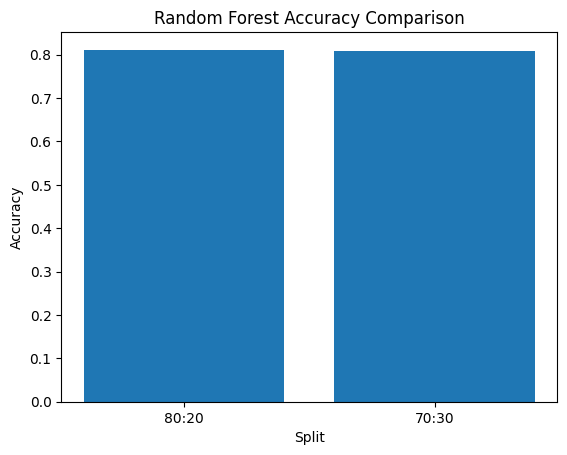

In [ ]:
rf_acc_80, rf_table_80 = rf_model(0.8)
splits = ['80:20', '70:30']
accuracies = [rf_acc_80, rf_acc_70]

plt.figure()
plt.bar(splits, accuracies)
plt.title("Random Forest Accuracy Comparison")
plt.xlabel("Split")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_scaled, y)

importance = model.feature_importances_

feature_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:")
print(feature_df)


Feature Importance:
             Feature  Importance
5     ProductQuality    0.226698
6     ServiceQuality    0.222098
4             Income    0.152080
0         CustomerID    0.102861
1                Age    0.102661
7  PurchaseFrequency    0.078472
3            Country    0.041712
9       LoyaltyLevel    0.028666
8      FeedbackScore    0.027403
2             Gender    0.017348


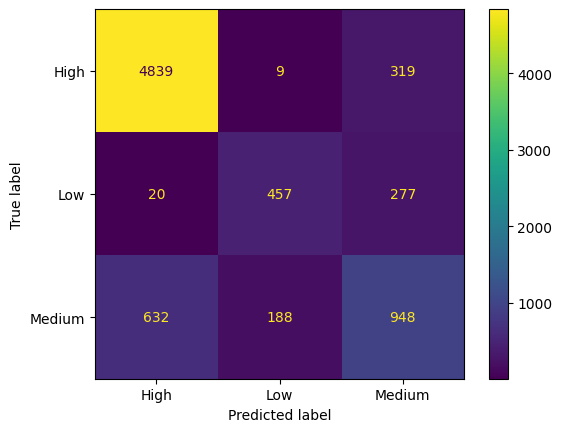

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

plt.show()

In [ ]:
# Take one sample
new_data = np.array([X.iloc[0]])
new_scaled = scaler.transform(new_data)

prediction = model.predict(new_scaled)

print("Predicted Output:", prediction)

Predicted Output: ['High']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
